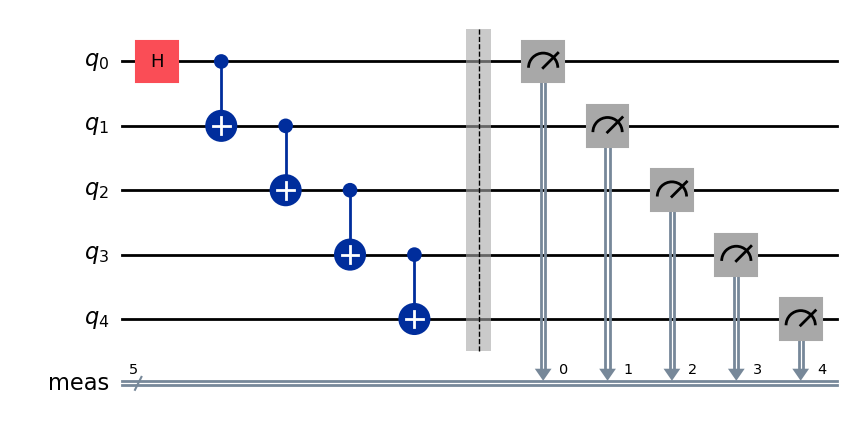

In [2]:
from qiskit import QuantumCircuit

def prepare_ghz(n_qubits:int):
    circuit = QuantumCircuit(n_qubits)
    circuit.h(0)
    for i in range(0, n_qubits-1):
        circuit.cx(i, i+1)

    circuit.measure_all()

    return circuit



qc = prepare_ghz(5)
qc_no_measure = prepare_ghz(5).remove_final_measurements(inplace=False)


qc.draw("mpl")


In [3]:
from qiskit.transpiler import generate_preset_pass_manager
from qiskit_ibm_runtime.fake_provider import FakeBrisbane

fbrisbane = FakeBrisbane()

pm_lvl3 = generate_preset_pass_manager(optimization_level=3, seed_transpiler=42, backend=fbrisbane)

transpiled_circuit = pm_lvl3.run(qc)

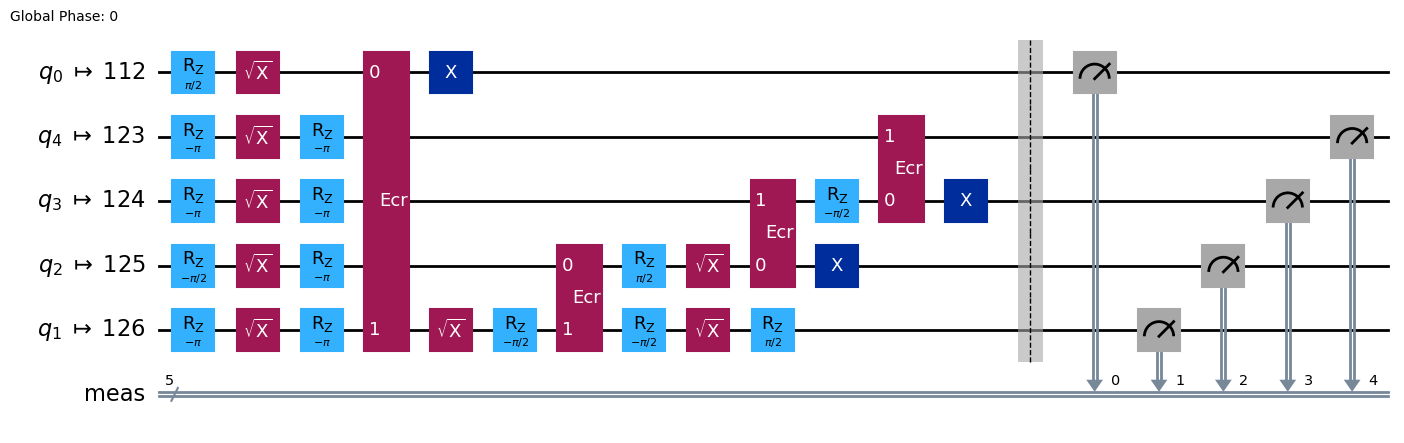

In [4]:
transpiled_circuit.draw("mpl")

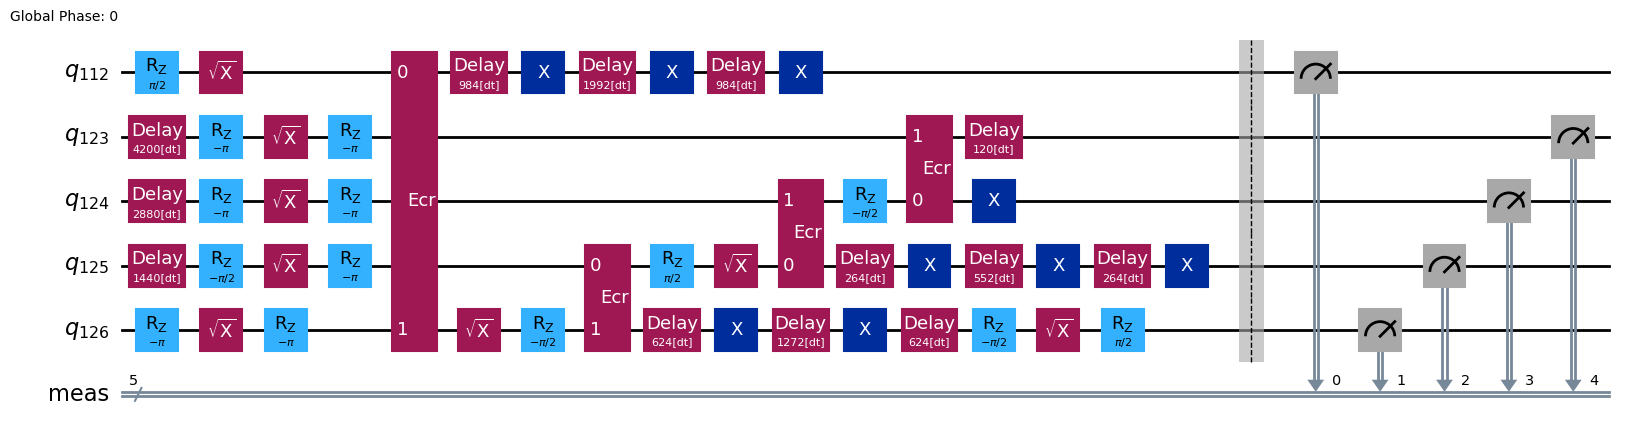

In [5]:
## Writing a CPMG DD pass using ALAP analysis

from qiskit.circuit.library import XGate
from qiskit.transpiler import PassManager
from qiskit.transpiler.passes.scheduling import ALAPScheduleAnalysis, PadDynamicalDecoupling

from qiskit.visualization.timeline import draw, IQXStandard

target_brisbane = fbrisbane.target
 
X = XGate()
 
dd_sequence = [X, X]

dd_alap_pm = PassManager(
    [
        ALAPScheduleAnalysis(target=target_brisbane),
        PadDynamicalDecoupling(target=target_brisbane, dd_sequence=dd_sequence),
    ]
)

dd_transpiled_circuit_alap = dd_alap_pm.run(transpiled_circuit)

dd_transpiled_circuit_alap.draw("mpl", idle_wires=False)

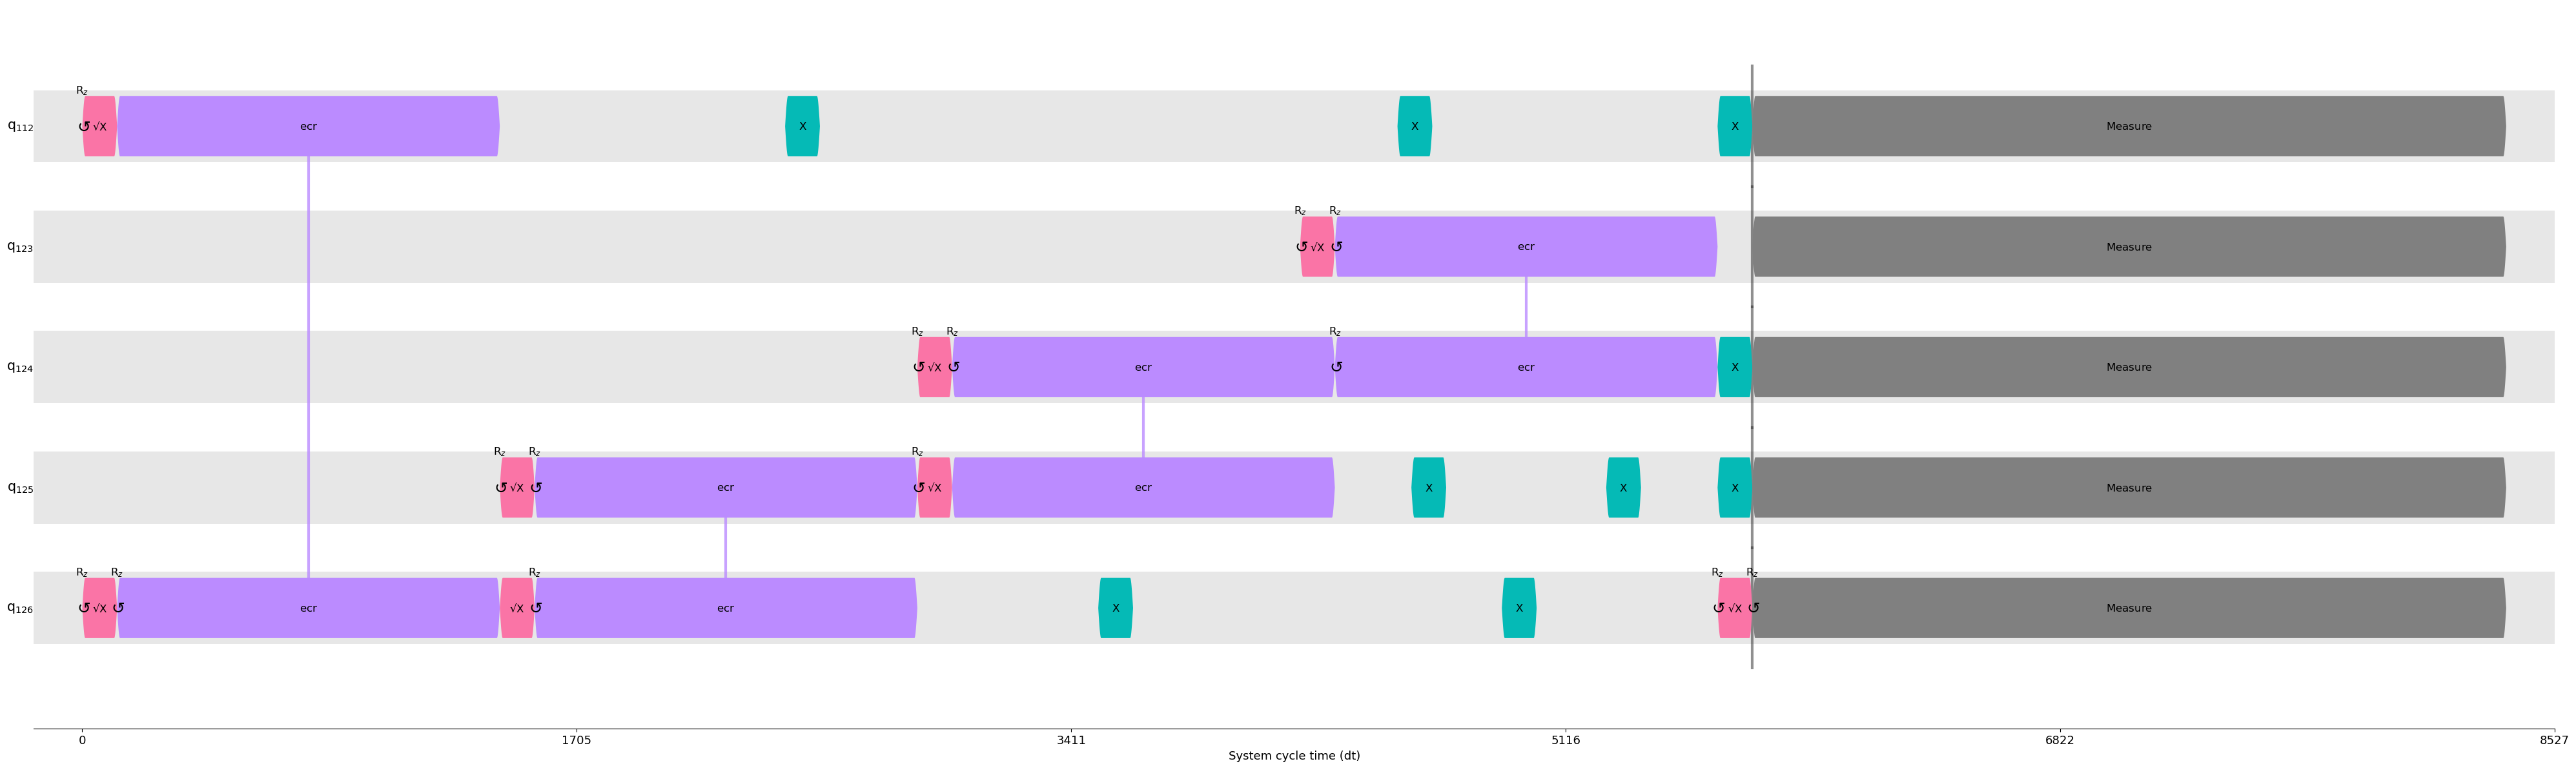

In [6]:
my_style = {
    'formatter.general.fig_width': 40,
    'formatter.general.fig_unit_height': 2,
}

draw(dd_transpiled_circuit_alap, target=target_brisbane, style=IQXStandard(**my_style), show_idle=False, show_delays=False)

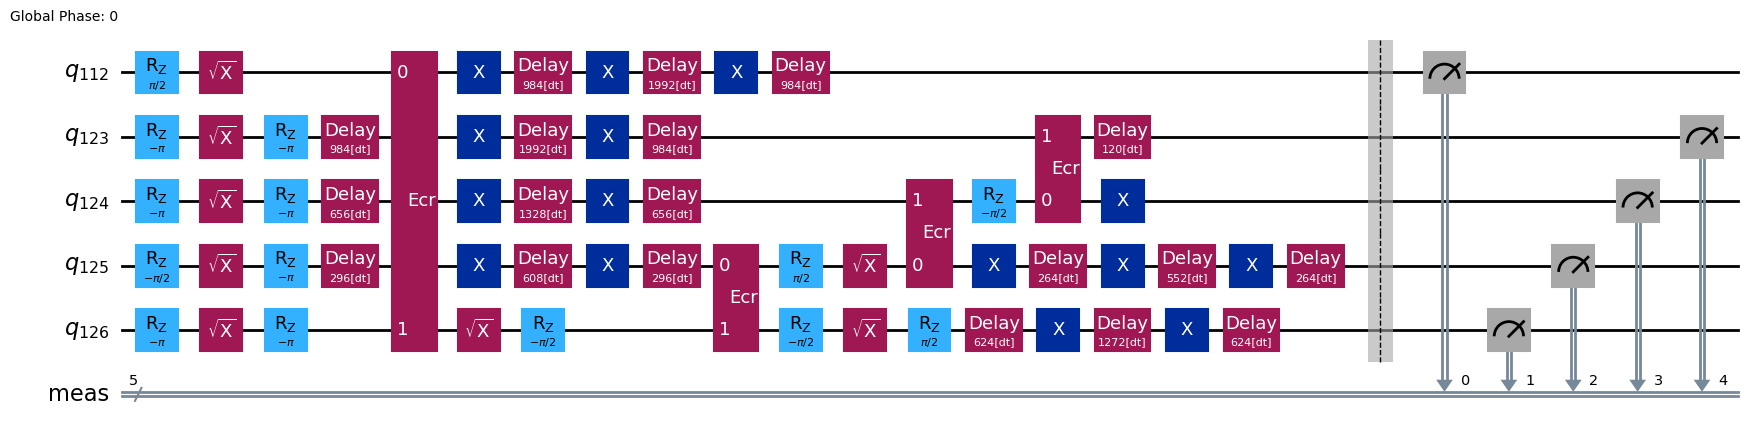

In [7]:
## Writing a CPMG DD pass using ALAP analysis

from qiskit.circuit.library import XGate
from qiskit.transpiler import PassManager
from qiskit.transpiler.passes.scheduling import ASAPScheduleAnalysis, PadDynamicalDecoupling

from qiskit.visualization.timeline import draw, IQXStandard

target_brisbane = fbrisbane.target
 
X = XGate()
 
dd_sequence = [X, X]

dd_asap_pm = PassManager(
    [
        ASAPScheduleAnalysis(target=target_brisbane),
        PadDynamicalDecoupling(target=target_brisbane, dd_sequence=dd_sequence),
    ]
)

dd_transpiled_circuit_asap = dd_asap_pm.run(transpiled_circuit)

dd_transpiled_circuit_asap.draw("mpl", idle_wires=False)

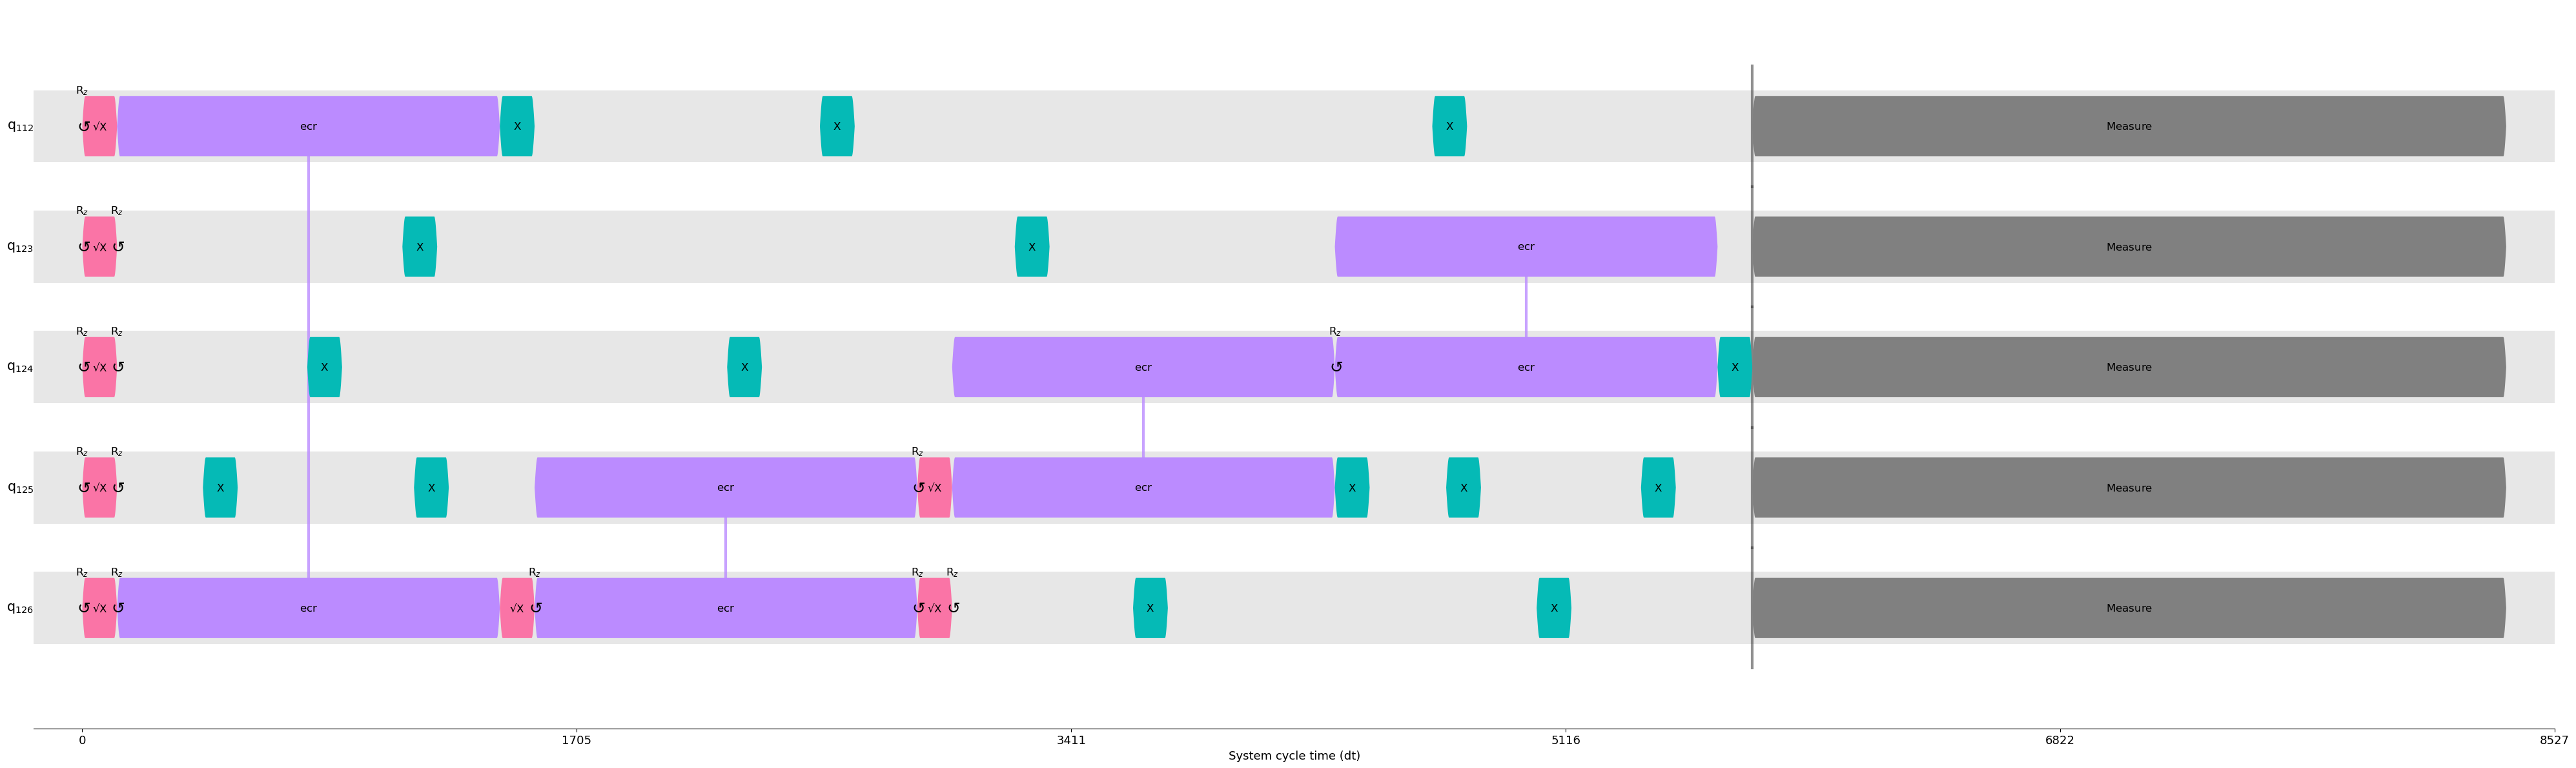

In [8]:
my_style = {
    'formatter.general.fig_width': 40,
    'formatter.general.fig_unit_height': 2,
}

draw(dd_transpiled_circuit_asap, target=target_brisbane, style=IQXStandard(**my_style), show_idle=False, show_delays=False)

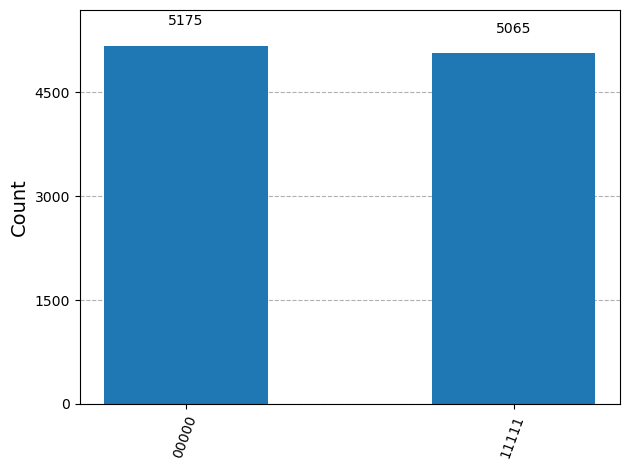

In [9]:
## Results from Noise model of Fake backend
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram

def execute_on_backend(transpiled_circuit:QuantumCircuit, simulator=AerSimulator(), noise_model=None):
    job = simulator.run(transpiled_circuit, shots=1024*10, noise_model=noise_model)
    result = job.result().get_counts()

    return result
    

sampled_res = execute_on_backend(transpiled_circuit, noise_model=None)

plot_histogram(sampled_res)

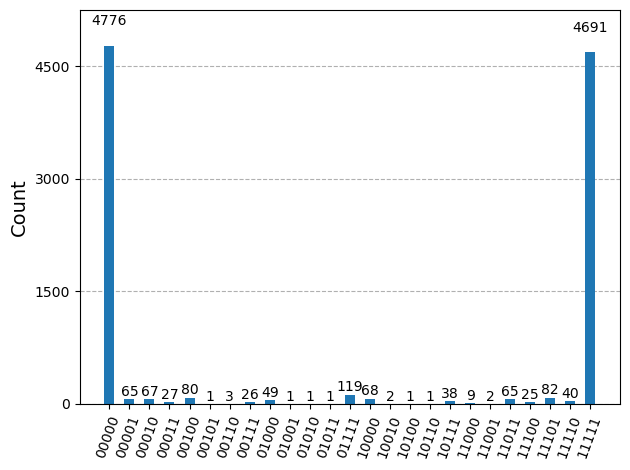

In [10]:
## Results from Noise model of Fake backend

from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel


brisbane_noise = NoiseModel.from_backend(fbrisbane)

brisbane_noisy_res = execute_on_backend(transpiled_circuit, noise_model=brisbane_noise)

plot_histogram(brisbane_noisy_res)

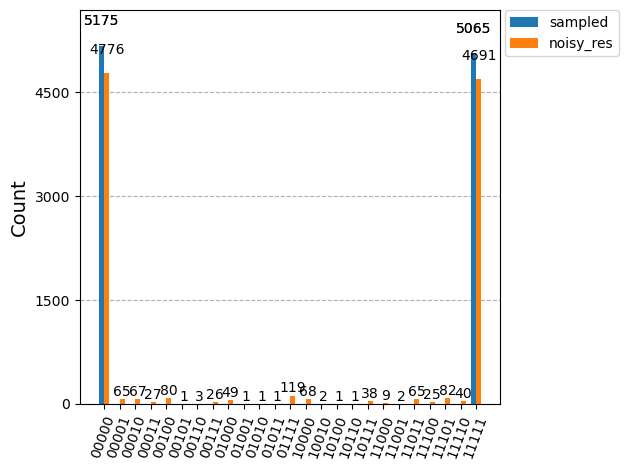

In [11]:
plot_histogram([sampled_res, brisbane_noisy_res], legend=["sampled", "noisy_res"])

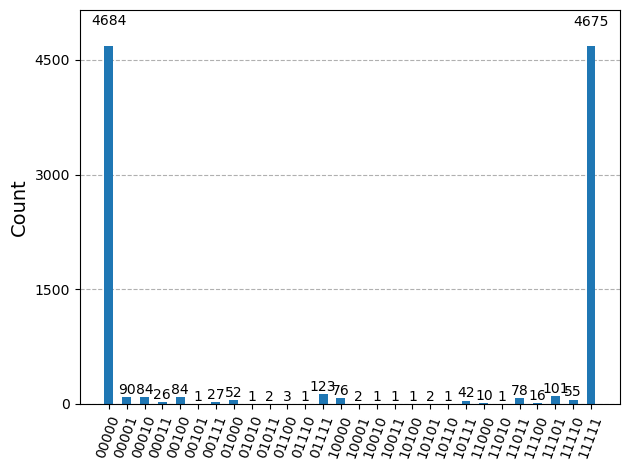

In [12]:
dd_brisbane_noisy_res_alap = execute_on_backend(dd_transpiled_circuit_alap, noise_model=brisbane_noise)
plot_histogram(dd_brisbane_noisy_res_alap)

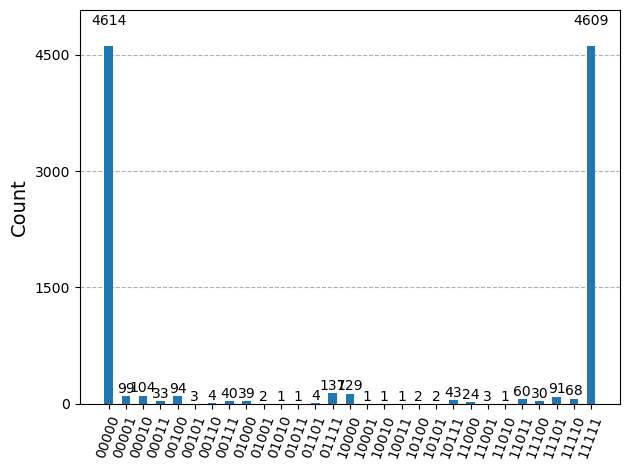

In [13]:
dd_brisbane_noisy_res_asap = execute_on_backend(dd_transpiled_circuit_asap, noise_model=brisbane_noise)
plot_histogram(dd_brisbane_noisy_res_asap)

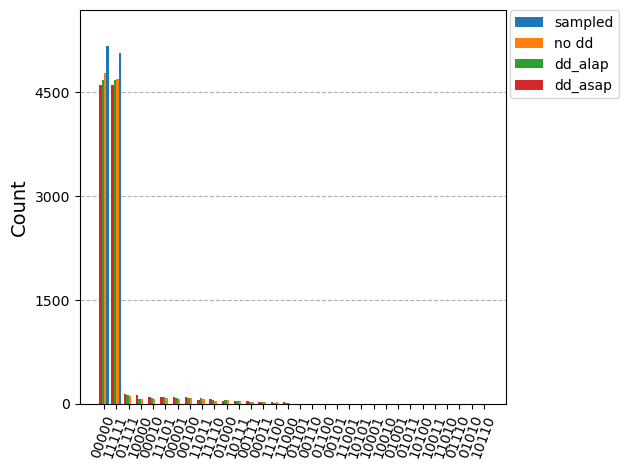

In [14]:
plot_histogram([sampled_res, brisbane_noisy_res, dd_brisbane_noisy_res_alap, dd_brisbane_noisy_res_asap], legend=['sampled', 'no dd', 'dd_alap', 'dd_asap'], sort='value_desc', 
               bar_labels=False)





In [15]:
def from_dict_to_probabilities(counts_dict:dict):
    
    total = sum(counts_dict.values())
    prob_dict = dict()
    for k in counts_dict:
        prob_dict[k] = counts_dict[k]/total

    return prob_dict



results_list = [sampled_res, brisbane_noisy_res, dd_brisbane_noisy_res_alap, dd_brisbane_noisy_res_asap]


probs_result_list = [from_dict_to_probabilities(probs_dict) for probs_dict in results_list]

for res_dict in results_list:
    print(len(res_dict))


2
25
28
29


In [ ]:
import pandas as pd
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)


result_df = pd.DataFrame(probs_result_list)
result_df.fillna(0, inplace=True)

result_df.index = ['sampled', 'no dd', 'dd_alap', 'dd_asap']


result_df

,11111,00000,10100,01011,10110,11001,01001,00101,11110,01010,00011,00111,00010,00100,01111,10010,10111,11100,00001,11101,00110,01000,10000,11011,11000,01110,10001,11010,01100,10011,10101,01101
sampled,0.494629,0.505371,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
no dd,0.458105,0.466406,0.000098,0.000098,0.000098,0.000195,0.000098,0.000098,0.003906,0.000098,0.002637,0.002539,0.006543,0.007812,0.011621,0.000195,0.003711,0.002441,0.006348,0.008008,0.000293,0.004785,0.006641,0.006348,0.000879,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
dd_alap,0.456543,0.457422,0.000098,0.000195,0.000098,0.000000,0.000000,0.000098,0.005371,0.000098,0.002539,0.002637,0.008203,0.008203,0.012012,0.000098,0.004102,0.001563,0.008789,0.009863,0.000000,0.005078,0.007422,0.007617,0.000977,0.000098,0.000195,0.000098,0.000293,0.000098,0.000195,0.000000
dd_asap,0.450098,0.450586,0.000195,0.000098,0.000000,0.000293,0.000195,0.000293,0.006641,0.000098,0.003223,0.003906,0.010156,0.009180,0.013379,0.000098,0.004199,0.002930,0.009668,0.008887,0.000391,0.003809,0.012598,0.005859,0.002344,0.000000,0.000098,0.000098,0.000000,0.000098,0.000195,0.000391


In [45]:
def metric_ghz(input_dict):
    num_qubit = len(list(input_dict.keys())[0])
    
    metric = input_dict['0'*num_qubit] + input_dict['1'*num_qubit]
    return metric

metric_ghz(probs_result_list[2])


0.92158203125

In [9]:
from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel
from qiskit import QuantumCircuit
from qiskit.transpiler import generate_preset_pass_manager, PassManager
from qiskit.transpiler.passes.scheduling import ALAPScheduleAnalysis, ASAPScheduleAnalysis, PadDynamicalDecoupling



def prepare_ghz(n_qubits:int):
    circuit = QuantumCircuit(n_qubits)
    circuit.h(0)
    for i in range(0, n_qubits-1):
        circuit.cx(i, i+1)

    circuit.measure_all()

    return circuit



def execute_on_noisy_backend(transpiled_circuit:QuantumCircuit, noise_model, simulator=AerSimulator()):
    job = simulator.run(transpiled_circuit, shots=1024*10, noise_model=noise_model)
    result = job.result().get_counts()

    return result




def from_counts_to_probabilities(counts_dict:dict):
    
    total = sum(counts_dict.values())
    prob_dict = dict()
    for k in counts_dict:
        prob_dict[k] = counts_dict[k]/total

    return prob_dict



def generate_experiment(num_qubits, fake_backend, schedule):
    circuit = prepare_ghz(num_qubits)

    pm = generate_preset_pass_manager(optimization_level=3, seed_transpiler=42, backend=fake_backend)

    transpiled_circuit = pm.run(circuit)

    from qiskit.circuit.library import XGate

    dd_sequence = [XGate(), XGate()]

    if schedule == 'asap':
        from qiskit.transpiler.passes.scheduling import ASAPScheduleAnalysis
        dd_pm = PassManager(
        [
            ASAPScheduleAnalysis(target=fake_backend.target),
            PadDynamicalDecoupling(target=fake_backend.target, dd_sequence=dd_sequence),
        ])

        dd_transpiled_circuit = dd_pm.run(transpiled_circuit)



    elif schedule=='alap':
        from qiskit.transpiler.passes.scheduling import ALAPScheduleAnalysis
        dd_pm = PassManager(
        [
            ALAPScheduleAnalysis(target=fake_backend.target),
            PadDynamicalDecoupling(target=fake_backend.target, dd_sequence=dd_sequence),
        ])

        dd_transpiled_circuit = dd_pm.run(transpiled_circuit)

    else:
        dd_transpiled_circuit = transpiled_circuit


    noise_model = NoiseModel.from_backend(fake_backend)

    res_dict = execute_on_noisy_backend(dd_transpiled_circuit, noise_model)

    return from_counts_to_probabilities(res_dict)


    

    

In [ ]:
from qiskit_ibm_runtime.fake_provider import FakeSherbrooke, FakeBrisbane, FakeTorino

backends = {"ftorino":FakeTorino(), "fbrisbane":FakeBrisbane(), "fsherbrooke":FakeSherbrooke()}

methods = ['', 'alap', 'asap']

def metric_ghz(input_dict):
    num_qubit = len(list(input_dict.keys())[0])
    
    metric = input_dict['0'*num_qubit] + input_dict['1'*num_qubit]
    return metric


exp_result_dict = dict()

for n in range(3, 20):
    for backend in backends.keys():
        for method in methods:
            print(f"Generating results for {n}-qubit GHZ state on {backend} backend with {method} schedueling")
            res_prob = generate_experiment(n, backends[backend], method)

            score = metric_ghz(res_prob)

            exp_result_dict[str(n)+'_'+backend+'_'+method] = score





            

Generating results for 3-qubit GHZ state on ftorino backend with  schedueling
Generating results for 3-qubit GHZ state on ftorino backend with alap schedueling
Generating results for 3-qubit GHZ state on ftorino backend with asap schedueling
Generating results for 3-qubit GHZ state on fbrisbane backend with  schedueling
Generating results for 3-qubit GHZ state on fbrisbane backend with alap schedueling
Generating results for 3-qubit GHZ state on fbrisbane backend with asap schedueling
Generating results for 3-qubit GHZ state on fsherbrooke backend with  schedueling
Generating results for 3-qubit GHZ state on fsherbrooke backend with alap schedueling
Generating results for 3-qubit GHZ state on fsherbrooke backend with asap schedueling
Generating results for 4-qubit GHZ state on ftorino backend with  schedueling
Generating results for 4-qubit GHZ state on ftorino backend with alap schedueling


Exception ignored in: <bound method IPythonKernel._clean_thread_parent_frames of <ipykernel.ipkernel.IPythonKernel object at 0x7e9d154bf650>>
Traceback (most recent call last):
  File "/home/aashay/anaconda3/envs/qamp/lib/python3.11/site-packages/ipykernel/ipkernel.py", line 781, in _clean_thread_parent_frames
    def _clean_thread_parent_frames(

KeyboardInterrupt: 


Generating results for 4-qubit GHZ state on ftorino backend with asap schedueling


In [ ]:
exp_result_dict